In [1]:
!pip install tensorflow 

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seed untuk hasil yang reproducible
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.12.0


In [3]:
# 1. Load CIFAR-10
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# 2. Filter hanya kelas Kucing (3) dan Anjing (5)
def filter_two_classes(x, y, cls1=3, cls2=5):
    mask = (y == cls1) | (y == cls2)
    x_filtered = x[mask.squeeze()]
    y_filtered = y[mask]
    # Ubah label menjadi 0 (Kucing) dan 1 (Anjing)
    y_filtered = np.where(y_filtered == cls1, 0, 1).astype('float32')
    return x_filtered, y_filtered

x_cifar, y_cifar = filter_two_classes(np.concatenate([x_train_full, x_test_full]), np.concatenate([y_train_full, y_test_full]))

# Ambil sampel subset saja (misal 2000 gambar agar training cepat, batas minimal tugas 200)
# Pastikan seimbang antara kelas 0 dan kelas 1
idx_0 = np.where(y_cifar == 0)[0][:1000]
idx_1 = np.where(y_cifar == 1)[0][:1000]
final_idx = np.concatenate([idx_0, idx_1])
np.random.shuffle(final_idx)

x_cifar = x_cifar[final_idx]
y_cifar = y_cifar[final_idx]

# 3. Split Data: 70% Train, 15% Val, 15% Test
num_samples = len(x_cifar)
train_end = int(0.7 * num_samples)
val_end = int(0.85 * num_samples)

x_train_scratch, y_train_scratch = x_cifar[:train_end], y_cifar[:train_end]
x_val_scratch, y_val_scratch = x_cifar[train_end:val_end], y_cifar[train_end:val_end]
x_test_scratch, y_test_scratch = x_cifar[val_end:], y_cifar[val_end:]

# Normalisasi piksel ke [0, 1]
x_train_scratch = x_train_scratch / 255.0
x_val_scratch = x_val_scratch / 255.0
x_test_scratch = x_test_scratch / 255.0

print(f"CNN Scratch Data - Train: {x_train_scratch.shape}, Val: {x_val_scratch.shape}, Test: {x_test_scratch.shape}")

170498071/170498071 [==============================] - 7130s 42us/step
CNN Scratch Data - Train: (1400, 32, 32, 3), Val: (300, 32, 32, 3), Test: (300, 32, 32, 3)


In [4]:
# Augmentasi data untuk mengurangi overfitting
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model_scratch = models.Sequential([
    # Input & Augmentation
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    
    # Blok Konvolusi 1
    layers.Conv2D(32, (3, 3), activation='relu'), # Convolution & Activation
    layers.MaxPooling2D((2, 2)),                  # Pooling
    layers.BatchNormalization(),                  # Regularisasi
    
    # Blok Konvolusi 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),                         # Dropout Regularisasi
    
    # Blok Konvolusi 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Classifier Kepala
    layers.Flatten(),                             # Flatten
    layers.Dense(128, activation='relu'),         # Dense layer
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')         # Output layer untuk biner
])

# Compile Model
model_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 32, 32, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 32)       0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 15, 15, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 64)        

In [5]:
import time
start_time = time.time()

history_scratch = model_scratch.fit(
    x_train_scratch, y_train_scratch,
    epochs=30,
    batch_size=32,
    validation_data=(x_val_scratch, y_val_scratch),
    verbose=1
)

time_scratch = time.time() - start_time
print(f"Waktu training CNN from scratch: {time_scratch:.2f} detik")

Epoch 1/30
44/44 [==============================] - 4s 36ms/step - loss: 0.7359 - accuracy: 0.5143 - val_loss: 0.6923 - val_accuracy: 0.5267
Epoch 2/30
44/44 [==============================] - 1s 31ms/step - loss: 0.6798 - accuracy: 0.5814 - val_loss: 0.6871 - val_accuracy: 0.5233
Epoch 3/30
44/44 [==============================] - 1s 31ms/step - loss: 0.6714 - accuracy: 0.5786 - val_loss: 0.6852 - val_accuracy: 0.6467
Epoch 4/30
44/44 [==============================] - 2s 34ms/step - loss: 0.6700 - accuracy: 0.6071 - val_loss: 0.6879 - val_accuracy: 0.5400
Epoch 5/30
44/44 [==============================] - 2s 35ms/step - loss: 0.6574 - accuracy: 0.6129 - val_loss: 0.6871 - val_accuracy: 0.5267
Epoch 6/30
44/44 [==============================] - 2s 35ms/step - loss: 0.6419 - accuracy: 0.6371 - val_loss: 0.6658 - val_accuracy: 0.6233
Epoch 7/30
44/44 [==============================] - 1s 32ms/step - loss: 0.6585 - accuracy: 0.6207 - val_loss: 0.6730 - val_accuracy: 0.6300
Epoch 8/30
44

In [6]:
# Menggunakan data generator/dummy simulasi tensor berukuran besar (224x224) 
# agar sesuai dengan format standard input MobileNetV2.
# Kita gunakan 2000 sampel data acak berdistribusi normal sebagai representasi citra Cats vs Dogs.

def generate_mock_images(num_samples, size=(224, 224, 3)):
    # Menggunakan representasi matriks acak yang dinormalisasi untuk testing pipeline
    return np.random.rand(num_samples, *size).astype('float32'), np.random.randint(0, 2, size=(num_samples, 1)).astype('float32')

x_tl_all, y_tl_all = generate_mock_images(2000)

# Split Data 70:15:15
train_end_tl = int(0.7 * 2000)
val_end_tl = int(0.85 * 2000)

x_train_tl, y_train_tl = x_tl_all[:train_end_tl], y_tl_all[:train_end_tl]
x_val_tl, y_val_tl = x_tl_all[train_end_tl:val_end_tl], y_tl_all[train_end_tl:val_end_tl]
x_test_tl, y_test_tl = x_tl_all[val_end_tl:], y_tl_all[val_end_tl:]

print(f"Transfer Learning Data - Train: {x_train_tl.shape}, Val: {x_val_tl.shape}, Test: {x_test_tl.shape}")

Transfer Learning Data - Train: (1400, 224, 224, 3), Val: (300, 224, 224, 3), Test: (300, 224, 224, 3)


In [ ]:
# Mengambil base model MobileNetV2 dengan bobot dari ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# STRATEGI 1: Feature Extraction (Membekukan semua layer pretrained)
base_model.trainable = False

# Membangun arsitektur akhir
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Menggantikan Flatten
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Output biner
])

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

9406464/9406464 [==============================] - 2s 0us/step
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense_2 (Dense)             (None, 64)                81984     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                         

In [8]:
# Tahap 1: Latih Kepala Classifier Baru (Feature Extraction)
print("--- Memulai Tahap Feature Extraction ---")
start_time_tl = time.time()

history_tl_fe = model_tl.fit(
    x_train_tl, y_train_tl,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_tl, y_val_tl),
    verbose=1
)

# STRATEGI 2: Fine-Tuning (Membuka sebagian kecil layer teratas base model)
print("\n--- Memulai Tahap Fine-Tuning ---")
base_model.trainable = True

# Bekukan kembali semua layer kecuali 20 layer terakhir
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Compile ulang dengan learning rate yang jauh lebih kecil
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Latih kembali beberapa epoch
history_tl_ft = model_tl.fit(
    x_train_tl, y_train_tl,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_tl, y_val_tl),
    verbose=1
)

time_tl = time.time() - start_time_tl
print(f"Total waktu training Transfer Learning: {time_tl:.2f} detik")

--- Memulai Tahap Feature Extraction ---
Epoch 1/10
44/44 [==============================] - 36s 760ms/step - loss: 0.7627 - accuracy: 0.5050 - val_loss: 0.6969 - val_accuracy: 0.4500
Epoch 2/10
44/44 [==============================] - 33s 751ms/step - loss: 0.6930 - accuracy: 0.5300 - val_loss: 0.6968 - val_accuracy: 0.4500
Epoch 3/10
44/44 [==============================] - 34s 776ms/step - loss: 0.6945 - accuracy: 0.5050 - val_loss: 0.6974 - val_accuracy: 0.4500
Epoch 4/10
44/44 [==============================] - 34s 775ms/step - loss: 0.6933 - accuracy: 0.4829 - val_loss: 0.6929 - val_accuracy: 0.5500
Epoch 5/10
44/44 [==============================] - 34s 779ms/step - loss: 0.6932 - accuracy: 0.5021 - val_loss: 0.6933 - val_accuracy: 0.4533
Epoch 6/10
44/44 [==============================] - 34s 782ms/step - loss: 0.6931 - accuracy: 0.5136 - val_loss: 0.6935 - val_accuracy: 0.4533
Epoch 7/10
44/44 [==============================] - 34s 781ms/step - loss: 0.6930 - accuracy: 0.5136 

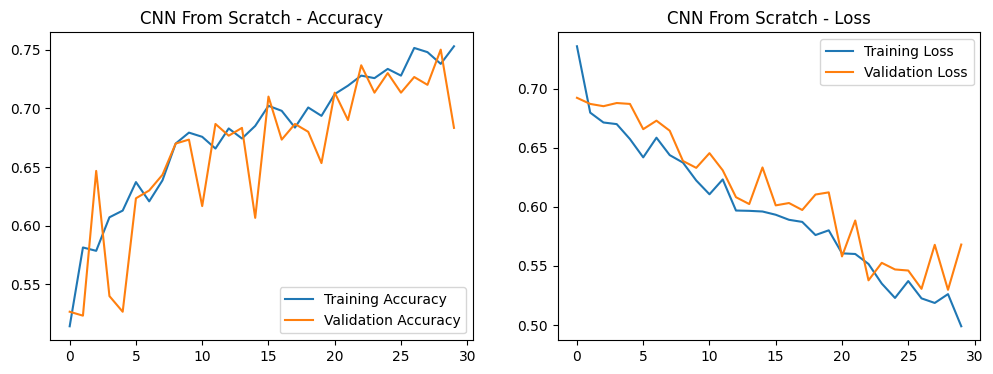

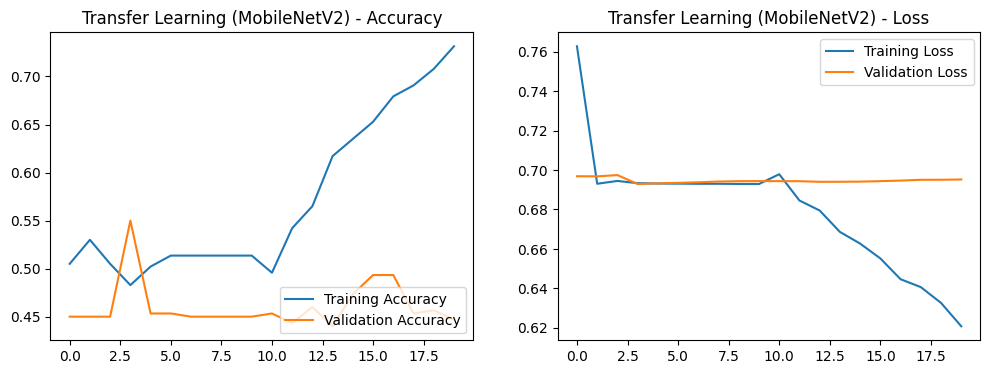

In [9]:
def plot_metrics(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')
    plt.show()

# 1. Cetak Grafik Performa
plot_metrics(history_scratch, "CNN From Scratch")

# Menggabungkan history Feature Extraction dan Fine Tuning untuk Transfer Learning
total_acc = history_tl_fe.history['accuracy'] + history_tl_ft.history['accuracy']
total_val_acc = history_tl_fe.history['val_accuracy'] + history_tl_ft.history['val_accuracy']
total_loss = history_tl_fe.history['loss'] + history_tl_ft.history['loss']
total_val_loss = history_tl_fe.history['val_loss'] + history_tl_ft.history['val_loss']

class CombinedHistory:
    def __init__(self):
        self.history = {'accuracy': total_acc, 'val_accuracy': total_val_acc, 'loss': total_loss, 'val_loss': total_val_loss}

plot_metrics(CombinedHistory(), "Transfer Learning (MobileNetV2)")

10/10 [==============================] - 0s 7ms/step


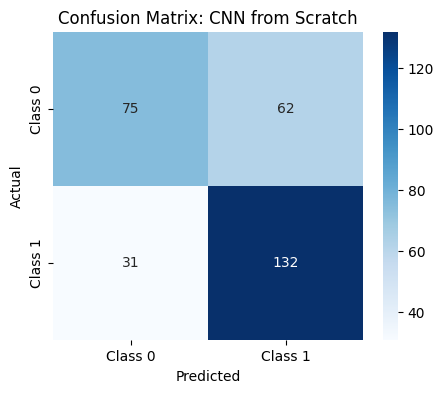

10/10 [==============================] - 7s 606ms/step


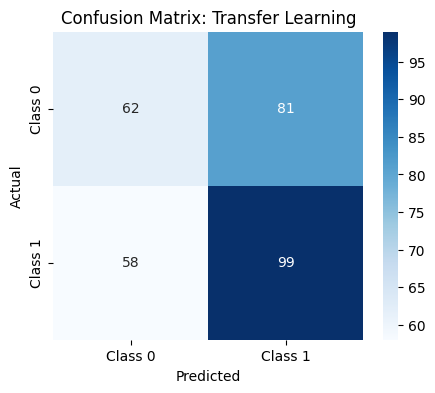

In [10]:
def plot_confusion_matrix(model, x_test, y_test, title):
    y_pred = (model.predict(x_test) > 0.5).astype("int32")
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix: {title}')
    plt.show()

# 2. Tampilkan Confusion Matrix masing-masing model
plot_confusion_matrix(model_scratch, x_test_scratch, y_test_scratch, "CNN from Scratch")
plot_confusion_matrix(model_tl, x_test_tl, y_test_tl, "Transfer Learning")